# Stream C

Cuts the slide into three magnifications (`level1/2/3`) and confirms the tiers
line up.

## Run the cutter (ratio ladder: 2x / 4x / 8x)
Tiles the whole slide three times. Use `parallel=True` for speed once Stream B runs clean; `parallel=False` while validating.

In [1]:
import cutter_wsidicom as C

SLIDE = ("/Users/yahyaamjad/Downloads/Research/cptac_brca/01BR001/2.25.48791557373299768401597362411459861639/SM_1.3.6.1.4.1.5962.99.1.132039251.338821108.1640809579091.2.0")   # <-- the folder
CUT_OUT = "./cut_out"

res = C.cutter(SLIDE, CUT_OUT, parallel=False)
res   # {m: {level, ft, eff, n_x, n_y, count, outdir}}

available downsamples (list index -> factor): {0: 1, 1: 4, 2: 16}
ladder: level1=(list 0, ft 2, eff 2x), level2=(list 1, ft 1, eff 4x), level3=(list 1, ft 2, eff 8x)

level1 -> list level 0 (downsample 1x), ft 2, effective 2x  ./cut_out/level1
slide: /Users/yahyaamjad/Downloads/Research/cptac_brca/01BR001/2.25.48791557373299768401597362411459861639/SM_1.3.6.1.4.1.5962.99.1.132039251.338821108.1640809579091.2.0
level_dimensions: [(57767, 21886), (14441, 5471), (3610, 1367)]
using list level 0 -> pyramid index 0, downsample 1x, size 57767x21886
grid: n_x=115, n_y=43, stepsize=500, tile=598
tiles kept: 485 -> ./cut_out/level1/dict.csv

level2 -> list level 1 (downsample 4x), ft 1, effective 4x  ./cut_out/level2
slide: /Users/yahyaamjad/Downloads/Research/cptac_brca/01BR001/2.25.48791557373299768401597362411459861639/SM_1.3.6.1.4.1.5962.99.1.132039251.338821108.1640809579091.2.0
level_dimensions: [(57767, 21886), (14441, 5471), (3610, 1367)]
using list level 1 -> pyramid index 2, downsampl

{1: {'list_level': 0,
  'downsample': 1,
  'ft': 2,
  'eff': 2,
  'n_x': 115,
  'n_y': 43,
  'count': 485,
  'outdir': './cut_out/level1'},
 2: {'list_level': 1,
  'downsample': 4,
  'ft': 1,
  'eff': 4,
  'n_x': 57,
  'n_y': 21,
  'count': 139,
  'outdir': './cut_out/level2'},
 3: {'list_level': 1,
  'downsample': 4,
  'ft': 2,
  'eff': 8,
  'n_x': 28,
  'n_y': 10,
  'count': 36,
  'outdir': './cut_out/level3'}}

## Display one matched tile across the three tiers

Finds a level-0 `(x, y)` that survived background filtering at all three levels,
then shows that same tissue corner at each magnification. Because coordinates are
stored in the shared level-0 frame, a matched tile has the *same top-left corner*;
the coarser tiers cover a wider field of view (each 299x299 output spans
`299 * effective_downsample` level-0 pixels).

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

def _coord_index(level_dir):
    df = pd.read_csv(os.path.join(level_dir, "dict.csv"))
    return {(int(r.X), int(r.Y)): r.Loc for r in df.itertuples()}

idx = {m: _coord_index(res[m]["outdir"]) for m in (1, 2, 3)}

# coords present at all three tiers (level3 is sparsest)
common = [xy for xy in idx[3] if xy in idx[2] and xy in idx[1]]
assert common, "no coordinate survived filtering at all 3 tiers - try raising blank_max"

# pick one near the centroid of the coarsest tier -> most likely solid tissue
import statistics as st
cx, cy = st.median(x for x, y in common), st.median(y for x, y in common)
px, py = min(common, key=lambda xy: (xy[0]-cx)**2 + (xy[1]-cy)**2)
print("matched level-0 coord:", (px, py))

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, m in zip(axes, (1, 2, 3)):
    eff = res[m]["eff"] # eff is a downsample factor: higher downsample, lower magnification 
    ax.imshow(Image.open(idx[m][(px, py)]).convert("RGB"))
    ax.set_title("level{}  eff {}x\nFOV {}px @ ({}, {})".format(m, eff, 299*eff, px, py))
    ax.axis("off")
plt.tight_layout(); plt.show()

matched level-0 coord: (16000, 14000)


In [3]:
paired = C.pair_region(CUT_OUT, fac=1000)   # -> DataFrame with L0/L1/L2 paths
print("surviving paired locations:", len(paired))
paired.head()

locations present at all three levels: 429
surviving paired locations: 429


,x,y,L0path,L1path,L2path
0,10,12,./cut_out/level1/region_x-10000-y-12000.png,./cut_out/level2/region_x-10000-y-12000.png,./cut_out/level3/region_x-10000-y-12000.png
1,10,12,./cut_out/level1/region_x-10000-y-12500.png,./cut_out/level2/region_x-10000-y-12000.png,./cut_out/level3/region_x-10000-y-12000.png
2,10,12,./cut_out/level1/region_x-10000-y-13000.png,./cut_out/level2/region_x-10000-y-13000.png,./cut_out/level3/region_x-10000-y-12000.png
3,10,12,./cut_out/level1/region_x-10000-y-13500.png,./cut_out/level2/region_x-10000-y-13000.png,./cut_out/level3/region_x-10000-y-12000.png
4,10,14,./cut_out/level1/region_x-10000-y-14000.png,./cut_out/level2/region_x-10000-y-14000.png,./cut_out/level3/region_x-10000-y-14000.png


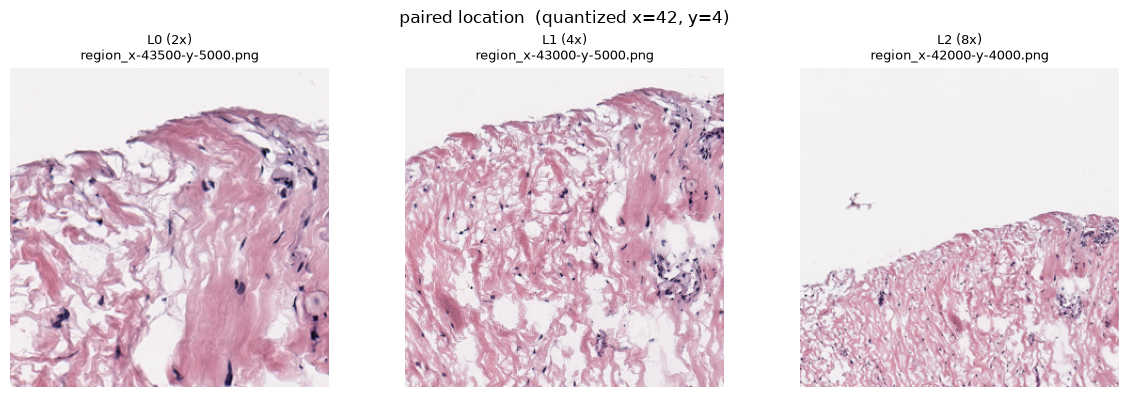

In [4]:
row = paired.iloc[len(paired) // 2]   # a location near the middle of the set
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col, tier in zip(axes, ["L0path", "L1path", "L2path"], ["L0 (2x)", "L1 (4x)", "L2 (8x)"]):
    ax.imshow(Image.open(row[col]).convert("RGB"))
    ax.set_title("{}\n{}".format(tier, __import__("os").path.basename(row[col])), fontsize=9)
    ax.axis("off")
plt.suptitle("paired location  (quantized x={}, y={})".format(row.x, row.y))
plt.tight_layout(); plt.show()

# Stream D

In [5]:
import glob
import numpy as np
from PIL import Image
import stain_wsidicom as SD
import stain_figures as SF

import matplotlib
matplotlib.use('QtAgg')  # Or use 'QtAgg' if you have PyQt installed
import matplotlib.pyplot as plt

# grab a representative tissue tile from the level1 output
tile_paths = sorted(glob.glob(os.path.join(CUT_OUT, "level1", "region_*.png")))
TILE = np.array(Image.open(tile_paths[len(tile_paths)//2]).convert("RGB"))
print("tile:", TILE.shape)

tile: (299, 299, 3)


In [6]:
SF.plot_d1_od(TILE); import matplotlib.pyplot as plt; plt.show()

In [7]:
SF.plot_d2_hed(TILE); plt.show()

In [8]:
%pip install torchstain

Note: you may need to restart the kernel to use updated packages.


In [10]:
REFERENCE = "colorstandard.png"   # or any well-stained reference tile path

norm = SD.StainNormalizer(method="macenko").fit_from_path(REFERENCE)

slide_tiles = {os.path.basename(p): np.array(Image.open(p).convert("RGB"))
               for p in tile_paths[:3]}
SF.plot_d3_normalization(slide_tiles, norm); plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'colorstandard.png'

In [ ]:
SF.plot_d4_qc(TILE); plt.show()
SD.qc_readout(TILE)   # the machine-readable QC dict